In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
dataframe = pd.read_csv("test_data.csv", index_col=0)
print(dataframe)

                            File   Status    Runtime  Runlength  quality  seed
0       ./storage/default7/1.txt    UNSAT   966.8330          0        0    -1
1       ./storage/default7/4.txt    UNSAT   178.4680          0        0    -1
2       ./storage/default7/5.txt    UNSAT    85.3295          0        0    -1
3       ./storage/default7/6.txt    UNSAT  1647.0200          0        0    -1
4       ./storage/default7/7.txt    UNSAT  1521.0100          0        0    -1
..                           ...      ...        ...        ...      ...   ...
178  ./storage/default7/1856.txt  SUCCESS    36.2545          0        0    -1
179  ./storage/default7/1857.txt  SUCCESS  2084.8800          0        0    -1
180  ./storage/default7/1858.txt  SUCCESS   371.6770          0        0    -1
181  ./storage/default7/1869.txt  SUCCESS   149.1110          0        0    -1
182  ./storage/default7/1881.txt  SUCCESS    32.7798          0        0    -1

[183 rows x 6 columns]


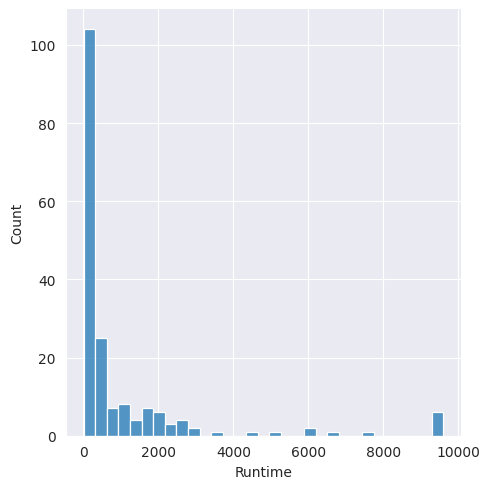

In [4]:
sns.displot(dataframe, x="Runtime")

In [5]:
print(dataframe["Runtime"].describe())

count     183.000000
mean     1025.037449
std      2011.007322
min         5.529900
25%        53.959500
50%       227.589000
75%       958.073500
max      9601.170000
Name: Runtime, dtype: float64


How about we optimize over everything above mean

In [6]:
print(dataframe["Status"].value_counts())

Status
SUCCESS    130
UNSAT       47
TIMEOUT      6
Name: count, dtype: int64


# Splitting test and training

In [9]:
train = []

with open("./aclib2/instances/mip/sets/SDPdMLPa-MIPVerify/training.txt") as file:
    line = file.readline()
    while line:
        number = line.split("/")[-1][4:-4]
        train.append(f"./storage/default7/{number}.txt")
        # print(number)
        # print(line.strip())
        line = file.readline()
    file.close()

print(train)
train_dataframe = dataframe[dataframe["File"].isin(train)]
display(train_dataframe)

['./storage/default7/1.txt', './storage/default7/4.txt', './storage/default7/5.txt', './storage/default7/6.txt', './storage/default7/7.txt', './storage/default7/11.txt', './storage/default7/12.txt', './storage/default7/13.txt', './storage/default7/14.txt', './storage/default7/15.txt', './storage/default7/18.txt', './storage/default7/20.txt', './storage/default7/21.txt', './storage/default7/22.txt', './storage/default7/23.txt', './storage/default7/24.txt', './storage/default7/26.txt', './storage/default7/27.txt', './storage/default7/28.txt', './storage/default7/29.txt', './storage/default7/30.txt', './storage/default7/31.txt', './storage/default7/32.txt', './storage/default7/33.txt', './storage/default7/35.txt', './storage/default7/34.txt', './storage/default7/63.txt', './storage/default7/64.txt', './storage/default7/93.txt', './storage/default7/116.txt', './storage/default7/120.txt', './storage/default7/134.txt', './storage/default7/145.txt', './storage/default7/152.txt', './storage/de

,File,Status,Runtime,Runlength,quality,seed
0,./storage/default7/1.txt,UNSAT,966.8330,0,0,-1
1,./storage/default7/4.txt,UNSAT,178.4680,0,0,-1
2,./storage/default7/5.txt,UNSAT,85.3295,0,0,-1
3,./storage/default7/6.txt,UNSAT,1647.0200,0,0,-1
4,./storage/default7/7.txt,UNSAT,1521.0100,0,0,-1
...,...,...,...,...,...,...
112,./storage/default7/884.txt,SUCCESS,114.2630,0,0,-1
113,./storage/default7/891.txt,SUCCESS,71.0128,0,0,-1
114,./storage/default7/899.txt,SUCCESS,22.6034,0,0,-1
115,./storage/default7/901.txt,SUCCESS,1290.0000,0,0,-1


count      92.000000
mean     1148.551835
std      2089.521849
min         6.082770
25%        55.294725
50%       243.361500
75%      1344.075000
max      9601.170000
Name: Runtime, dtype: float64
Status
SUCCESS    66
UNSAT      23
TIMEOUT     3
Name: count, dtype: int64


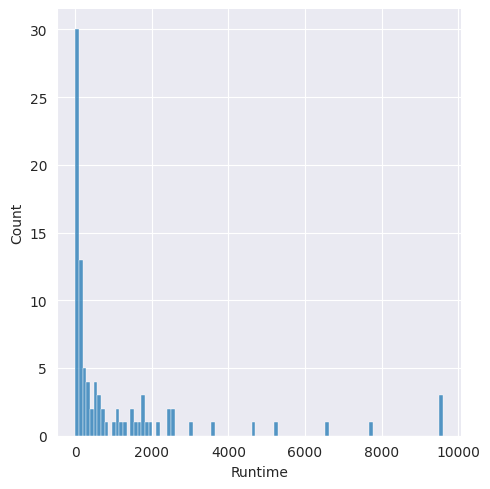

In [10]:
sns.displot(train_dataframe, x="Runtime", bins=100)
print(train_dataframe["Runtime"].describe())
print(train_dataframe["Status"].value_counts())

This kinda makes me think we can get away with optimizing with a WAAYYYYY lower capped runtime like 40_000 without actually losing much....
But again this could be because of default, but it's the standard we're trying to beat, so in that regard it wouln't matter.

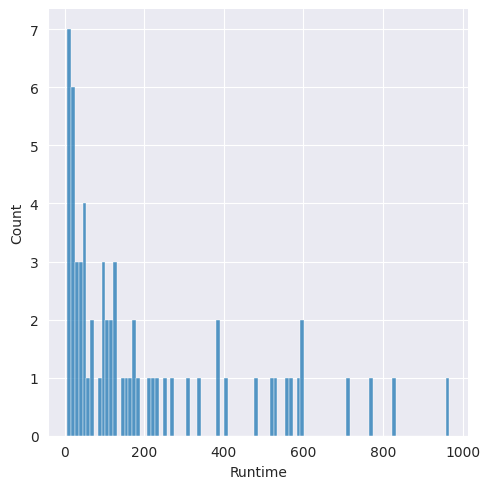

In [11]:
sns.displot(train_dataframe[train_dataframe["Runtime"] < 1000], x="Runtime", bins=100)


### Test examples

In [12]:
test = []

with open("./aclib2/instances/mip/sets/SDPdMLPa-MIPVerify/test.txt") as file:
    line = file.readline()
    while line:
        number = line.split("/")[-1][4:-4]
        test.append(f"./storage/default7/{number}.txt")
        # print(number)
        # print(line.strip())
        line = file.readline()
    file.close()

print(test)
test_dataframe = dataframe[dataframe["File"].isin(test)]
display(test_dataframe)

['./storage/default7/36.txt', './storage/default7/37.txt', './storage/default7/38.txt', './storage/default7/40.txt', './storage/default7/43.txt', './storage/default7/49.txt', './storage/default7/50.txt', './storage/default7/51.txt', './storage/default7/52.txt', './storage/default7/53.txt', './storage/default7/55.txt', './storage/default7/56.txt', './storage/default7/57.txt', './storage/default7/58.txt', './storage/default7/61.txt', './storage/default7/68.txt', './storage/default7/69.txt', './storage/default7/70.txt', './storage/default7/71.txt', './storage/default7/72.txt', './storage/default7/75.txt', './storage/default7/77.txt', './storage/default7/80.txt', './storage/default7/81.txt', './storage/default7/82.txt', './storage/default7/927.txt', './storage/default7/931.txt', './storage/default7/961.txt', './storage/default7/983.txt', './storage/default7/1018.txt', './storage/default7/1033.txt', './storage/default7/1069.txt', './storage/default7/1073.txt', './storage/default7/1083.txt',

,File,Status,Runtime,Runlength,quality,seed
26,./storage/default7/36.txt,UNSAT,187.3250,0,0,-1
27,./storage/default7/37.txt,UNSAT,540.6040,0,0,-1
28,./storage/default7/38.txt,UNSAT,645.1540,0,0,-1
29,./storage/default7/40.txt,UNSAT,2763.6000,0,0,-1
30,./storage/default7/43.txt,UNSAT,1686.8800,0,0,-1
...,...,...,...,...,...,...
178,./storage/default7/1856.txt,SUCCESS,36.2545,0,0,-1
179,./storage/default7/1857.txt,SUCCESS,2084.8800,0,0,-1
180,./storage/default7/1858.txt,SUCCESS,371.6770,0,0,-1
181,./storage/default7/1869.txt,SUCCESS,149.1110,0,0,-1


count      91.000000
mean      900.165761
std      1931.889256
min         5.529900
25%        53.959500
50%       223.287000
75%       586.660000
max      9601.160000
Name: Runtime, dtype: float64
Status
SUCCESS    64
UNSAT      24
TIMEOUT     3
Name: count, dtype: int64


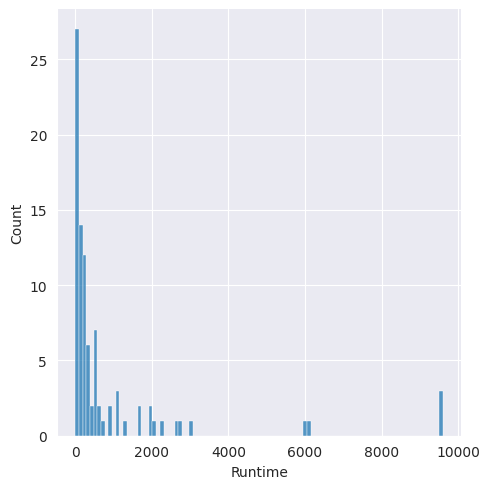

In [13]:
sns.displot(test_dataframe, x="Runtime", bins=100)
print(test_dataframe["Runtime"].describe())
print(test_dataframe["Status"].value_counts())

# Log-laplacian transform

In [14]:
def log_laplace(t, k_0, alpha=1):
    all = []
    for item in t:
        if item < k_0:
            all.append(1 - 0.5* (item/k_0)**alpha)
        else:
            all.append(0.5*(k_0/item)**alpha)
    return np.array(all)

In [15]:
def uniform_util(t, k_0, alpha=1):
    all = []
    for item in t:
        if item < k_0:
            all.append(1 - (item/k_0))
        else:
            all.append(0)
    return np.array(all)

<Axes: >

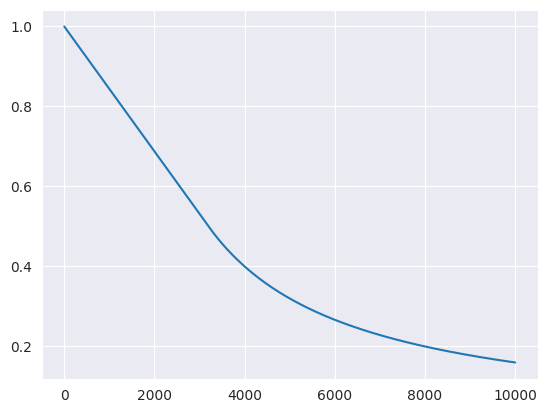

In [16]:
point = np.arange(0, 10_000, 1)
outs = log_laplace(point, 3200)
sns.lineplot(x=point, y=outs)

<Axes: >

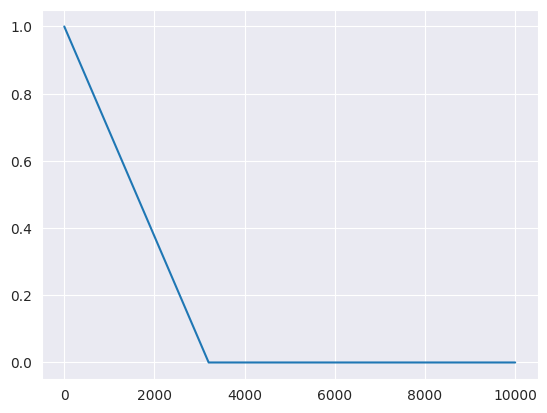

In [17]:
point = np.arange(0, 10_000, 1)
outs = uniform_util(point, 3200)
sns.lineplot(x=point, y=outs)

In [18]:
train_dataframe_copy = train_dataframe.copy(deep=True)

TODO: Why does it use k_0 and if longer then 0, wouldnt that mean doubling the captime doesnt do anything as they get no utility?

Figured it out, untill k_0 is is linear, then after it lowers more slowly, at least for log-laplace (check above)
For uniform I have no clue.

In [22]:
k_0 = 250 #1000

In [24]:
train_dataframe_copy["Utility"] = log_laplace(train_dataframe_copy["Runtime"], k_0=k_0)

Using 1000 here because its the mean, but we could probably do a lot lower, maybe even 250 because 50% of the data is below this, but not a good idea as linear decrease up to this point
But what would we set a k_0, probably 250 and not 1000, because we will double anyway...

Should we aim for a utility function that follows the distribution of the actual samples of the baseline (default)?


<Axes: >

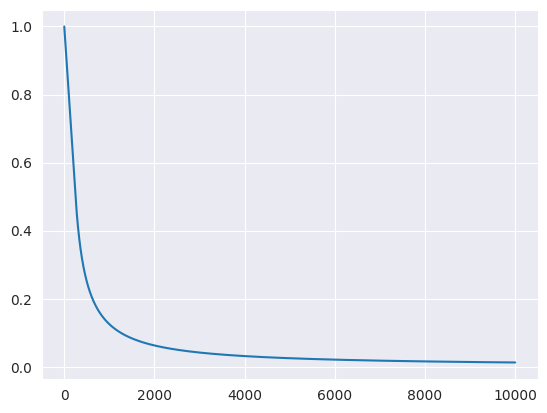

In [26]:
point = np.arange(0, 10_000, 1)
outs = log_laplace(point, k_0=k_0)
sns.lineplot(x=point, y=outs)

count    92.000000
mean      0.492987
std       0.372504
min       0.013019
25%       0.093421
50%       0.513327
75%       0.889411
max       0.987834
Name: Utility, dtype: float64


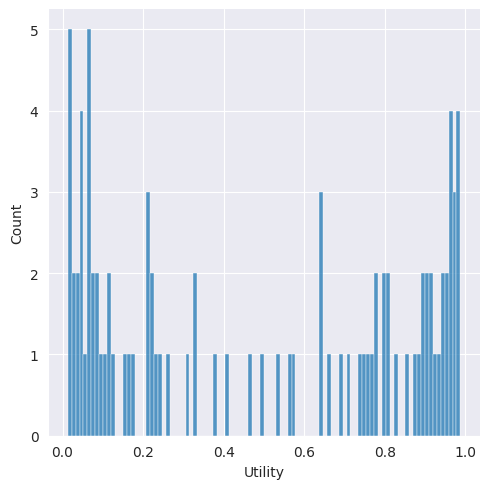

In [27]:
sns.displot(train_dataframe_copy, x="Utility", bins=100)
print(train_dataframe_copy["Utility"].describe())

# Projecting upper and lower confidence bounds by sampling